In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
from glob import glob
from PIL import Image
import random

from collections import defaultdict
import shutil
from glob import glob
from tqdm import tqdm

In [ ]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

--2025-05-19 22:56:56--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2025-05-19 22:56:57--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  16.0MB/s    in 49s     

2025-05-19 22:57:47 (15.3 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]

--2025-05-19 22:57:48--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.r

In [ ]:
image_paths = sorted(glob('images/*.jpg'))
classes = sorted(set([os.path.basename(path).rsplit('_', 1)[0].lower() for path in image_paths]))
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}

sample_classes = random.sample(classes, 10)


In [ ]:
print(f"Total classes: {len(classes)}")
print("First 10 class names:")
print(classes[:10])


# Count images per class
image_counts = defaultdict(int)

for path in image_paths:
    class_name = os.path.basename(path).rsplit('_', 1)[0].lower()
    image_counts[class_name] += 1

# Convert to sorted list of tuples
sorted_counts = sorted(image_counts.items(), key=lambda x: x[0])

for cls, count in sorted_counts:
    print(f"{cls}: {count} images")

Total classes: 37
First 10 class names:
['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair']
abyssinian: 200 images
american_bulldog: 200 images
american_pit_bull_terrier: 200 images
basset_hound: 200 images
beagle: 200 images
bengal: 200 images
birman: 200 images
bombay: 200 images
boxer: 200 images
british_shorthair: 200 images
chihuahua: 200 images
egyptian_mau: 200 images
english_cocker_spaniel: 200 images
english_setter: 200 images
german_shorthaired: 200 images
great_pyrenees: 200 images
havanese: 200 images
japanese_chin: 200 images
keeshond: 200 images
leonberger: 200 images
maine_coon: 200 images
miniature_pinscher: 200 images
newfoundland: 200 images
persian: 200 images
pomeranian: 200 images
pug: 200 images
ragdoll: 200 images
russian_blue: 200 images
saint_bernard: 200 images
samoyed: 200 images
scottish_terrier: 199 images
shiba_inu: 200 images
siamese: 200 images
sphynx: 200 i

In [ ]:
#Clean into subfolders
output_dir = "pet_images_by_class"
os.makedirs(output_dir, exist_ok=True)

for filepath in tqdm(glob("images/*.jpg")):
    filename = os.path.basename(filepath)
    class_name = filename.rsplit("_", 1)[0].lower()
    class_path = os.path.join(output_dir, class_name)
    os.makedirs(class_path, exist_ok=True)
    shutil.copy(filepath, class_path)


100%|██████████| 7390/7390 [00:02<00:00, 2837.61it/s]


In [ ]:
def plot_training_history(history, model_name="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, 'o-', label='Train Acc', linewidth=2, markersize=6)
    plt.plot(epochs_range, val_acc, 's--', label='Val Acc', linewidth=2, markersize=6)
    plt.title(f'{model_name} - Accuracy per Epoch', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, 'o-', label='Train Loss', linewidth=2, markersize=6)
    plt.plot(epochs_range, val_loss, 's--', label='Val Loss', linewidth=2, markersize=6)
    plt.title(f'{model_name} - Loss per Epoch', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    "pet_images_by_class",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "pet_images_by_class",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 7390 files belonging to 37 classes.
Using 5912 files for training.
Found 7390 files belonging to 37 classes.
Using 1478 files for validation.


In [ ]:
import tensorflow as tf

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def create_cnn_model(input_shape=(160, 160, 3), num_classes=37):
    model = keras.Sequential([
        data_augmentation,
        layers.Rescaling(1./255, input_shape=input_shape),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dropout(0.5),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = create_cnn_model(input_shape=(160, 160, 3), num_classes=num_classes)

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


370/370 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.0309 - loss: 3.6288 - val_accuracy: 0.0555 - val_loss: 3.5345
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.0830 - loss: 3.4207 - val_accuracy: 0.1198 - val_loss: 3.2453
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1052 - loss: 3.2365 - val_accuracy: 0.1245 - val_loss: 3.1213
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.1423 - loss: 3.1306 - val_accuracy: 0.1387 - val_loss: 3.1088
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1586 - loss: 3.0417 - val_accuracy: 0.1597 - val_loss: 3.0225
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.1794 - loss: 2.9811 - val_accuracy: 0.1773 - val_loss: 2.9755
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1910 - loss: 2.9202 - val_accuracy: 0.1949 - val_loss: 2.9045
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.1933 - loss: 2.8970 - val_accuracy: 0.

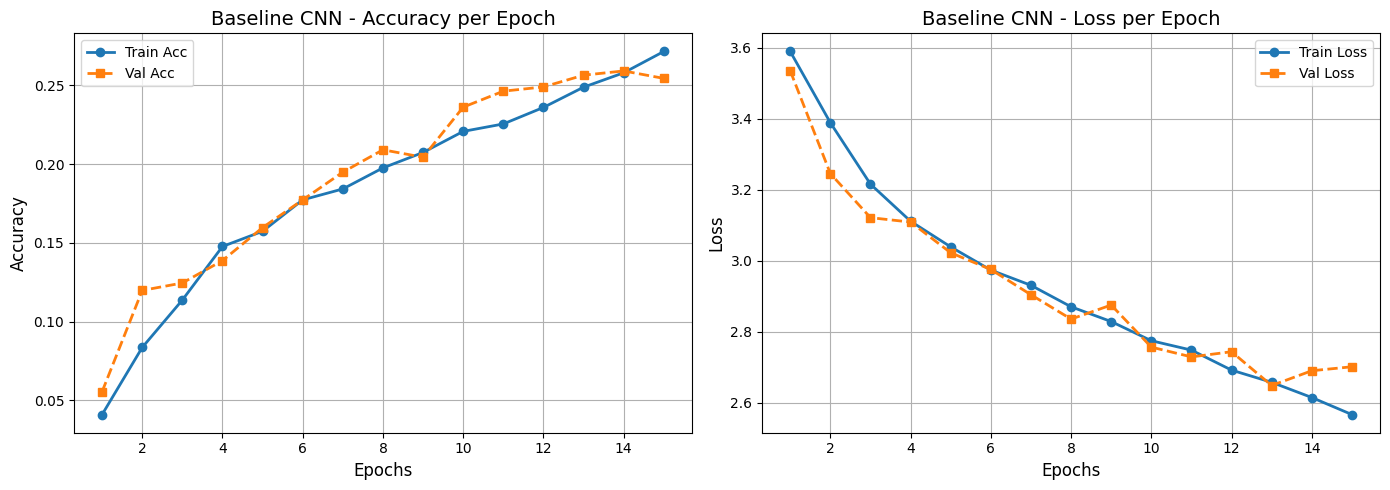

In [ ]:
plot_training_history(history, model_name="Baseline CNN")

In [ ]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = cnn_model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1 = report['macro avg']['f1-score']
accuracy = report['accuracy']

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, callbacks

IMG_SIZE = (160, 160)
input_shape = IMG_SIZE + (3,)

# Load EfficientNetB0 base
base_model = EfficientNetB0(
    input_shape=input_shape,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=input_shape)
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

efficientnet_model = models.Model(inputs, outputs)


efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history1 = efficientnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 49s 73ms/step - accuracy: 0.6135 - loss: 1.7254 - val_accuracy: 0.8884 - val_loss: 0.4164
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9060 - loss: 0.3503 - val_accuracy: 0.8945 - val_loss: 0.3283
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9372 - loss: 0.2341 - val_accuracy: 0.9012 - val_loss: 0.3003
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9483 - loss: 0.1904 - val_accuracy: 0.9032 - val_loss: 0.2956
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9648 - loss: 0.1470 - val_accuracy: 0.8978 - val_loss: 0.2944
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9684 - loss: 0.1266 - val_accuracy: 0.9060 - val_loss: 0.2855
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9768 - loss: 0.1079 - val_accuracy: 0.9060 - val_loss: 0.2847
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 11s 

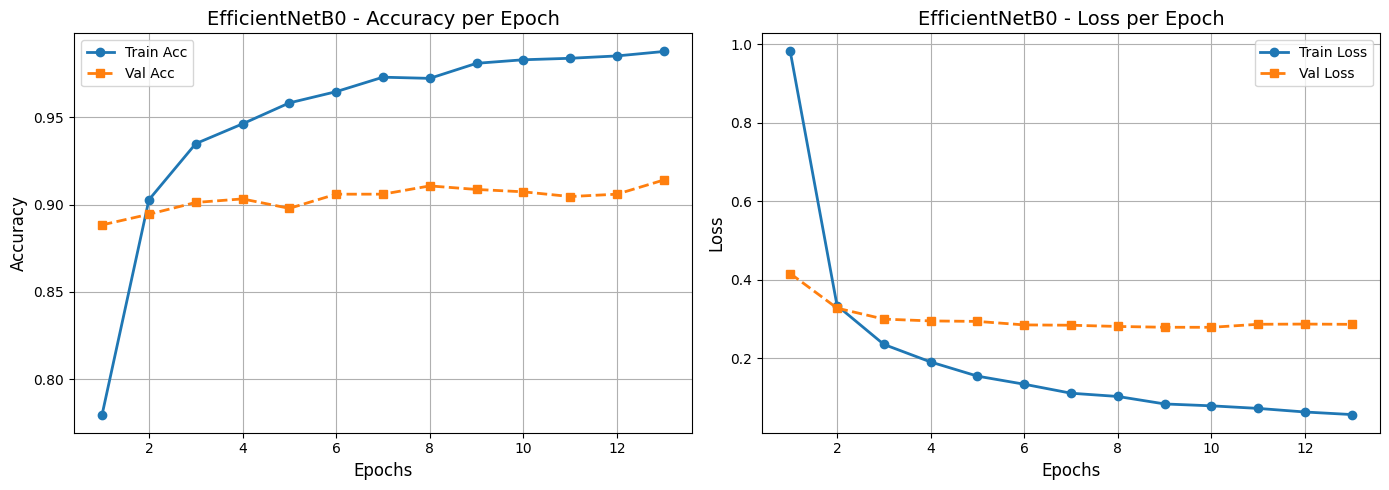

In [ ]:
plot_training_history(history1, model_name="EfficientNetB0")

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = efficientnet_model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1 = report['macro avg']['f1-score']
accuracy = report['accuracy']

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━

In [ ]:
from tensorflow.keras import layers, models, callbacks

mlp_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=IMG_SIZE + (3,)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history2 = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


370/370 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.0278 - loss: 15.4616 - val_accuracy: 0.0203 - val_loss: 3.6120
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0289 - loss: 3.6315 - val_accuracy: 0.0203 - val_loss: 3.6127
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0308 - loss: 3.6111 - val_accuracy: 0.0203 - val_loss: 3.6133
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0348 - loss: 3.6110 - val_accuracy: 0.0203 - val_loss: 3.6138


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, callbacks

base_model = VGG16(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.vgg16.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

vgg16_model = models.Model(inputs, outputs)

vgg16_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history3 = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop]
)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 38s 87ms/step - accuracy: 0.1706 - loss: 16.6127 - val_accuracy: 0.6631 - val_loss: 2.5636
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5928 - loss: 3.9109 - val_accuracy: 0.7382 - val_loss: 1.9071
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.6813 - loss: 2.5285 - val_accuracy: 0.7524 - val_loss: 1.8515
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 41s 67ms/step - accuracy: 0.7600 - loss: 1.6585 - val_accuracy: 0.7686 - val_loss: 1.8126
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.7781 - loss: 1.4255 - val_accuracy: 0.7930 - val_loss: 1.4610
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 24s 65ms/step - accuracy: 0.8056 - loss: 1.2747 - val_accuracy: 0.7713 - val_loss: 1.9488
Epoch 7/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.8165 - loss: 1.1903 - val_accuracy: 0.7740 - val_loss: 1.7551
Epoch 8/15
370/370 ━━━━━━━━━━━━━━━━━━━

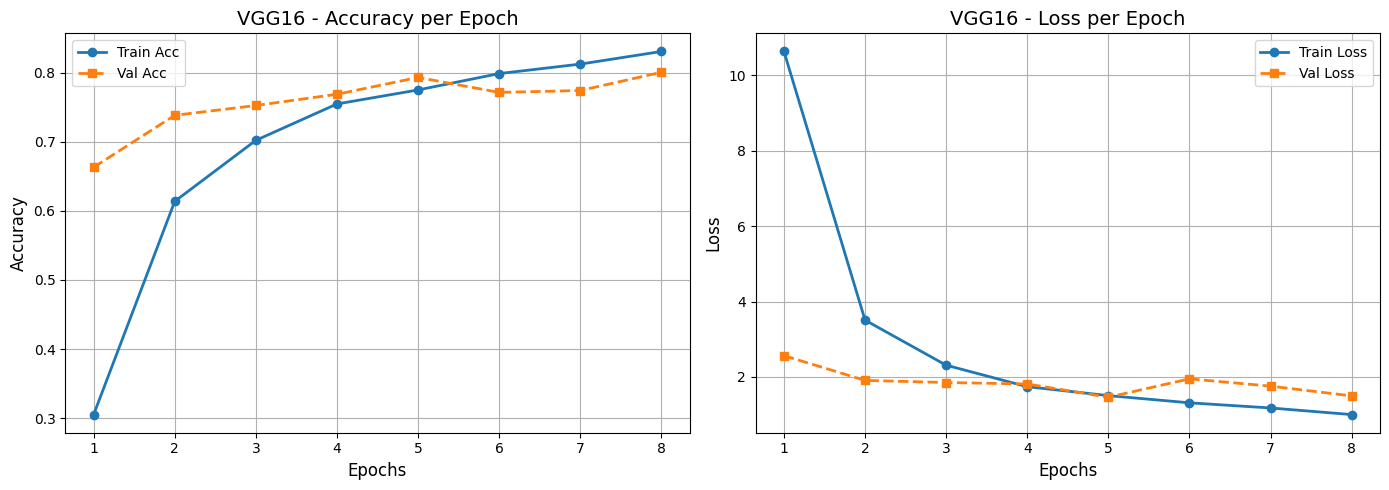

In [ ]:
plot_training_history(history3, model_name="VGG16")

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = vgg16_model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1 = report['macro avg']['f1-score']
accuracy = report['accuracy']

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history4 = model.fit(train_ds,
                    validation_data=val_ds,
                    callbacks=[early_stop],
                    epochs=15)


Epoch 1/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - accuracy: 0.5243 - loss: 1.7803 - val_accuracy: 0.8194 - val_loss: 0.5504
Epoch 2/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8538 - loss: 0.4644 - val_accuracy: 0.8403 - val_loss: 0.4812
Epoch 3/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8973 - loss: 0.3084 - val_accuracy: 0.8572 - val_loss: 0.4733
Epoch 4/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9123 - loss: 0.2608 - val_accuracy: 0.8457 - val_loss: 0.5029
Epoch 5/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9334 - loss: 0.1995 - val_accuracy: 0.8451 - val_loss: 0.5187
Epoch 6/15
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9468 - loss: 0.1599 - val_accuracy: 0.8484 - val_loss: 0.5257


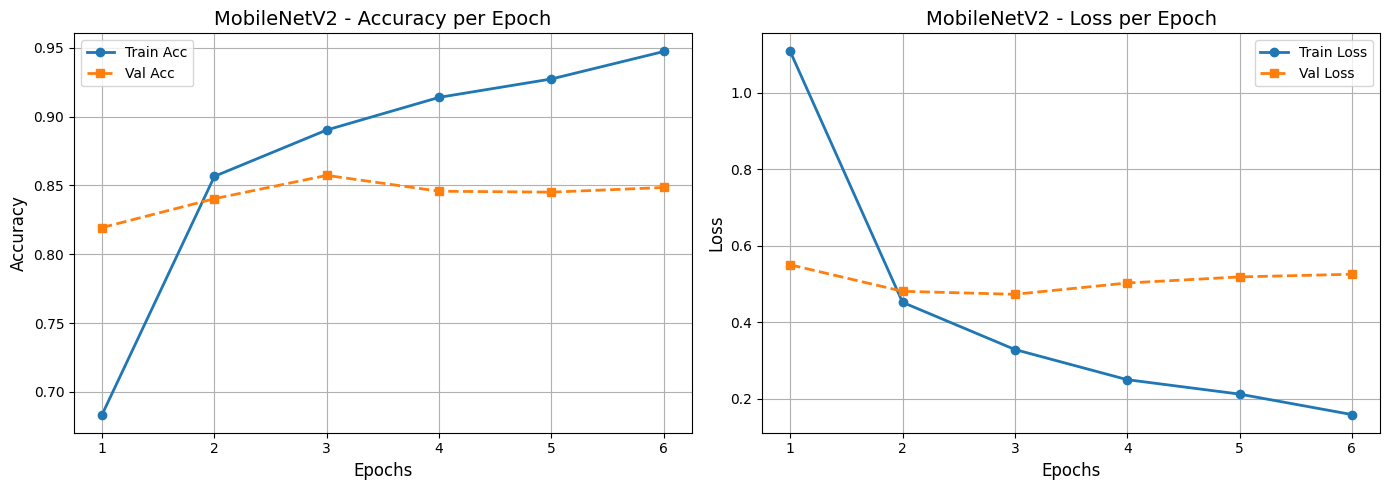

In [ ]:
plot_training_history(history4, model_name="MobileNetV2")

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds_classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(preds_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)


report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1 = report['macro avg']['f1-score']
accuracy = report['accuracy']

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━